In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras as ks
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import layers, models, optimizers, callbacks
import matplotlib.pyplot as plt

df = pd.read_csv("/content/data.csv")



In [ ]:
df.index = pd.date_range(start="2024-01-01", periods=len(df), freq="H")


restormel_features = [col for col in df.columns if "Restormel" in col]
target_col = "Restormel 10SRE01"

X_all = df[restormel_features]


y_target = df[[target_col]]

#normalise features
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = x_scaler.fit_transform(X_all)
y_scaled = y_scaler.fit_transform(y_target)

#indowing parameters (need to be altered depending on forecast sequence length)
lookback = 168  # past week
horizon = 168

#encoder-decoder sequences
def create_seq2seq_data(X, y, lookback, horizon):
    X_enc, X_dec, y_dec = [], [], []
    for i in range(len(X) - lookback - horizon + 1):
        X_enc.append(X[i:i+lookback])          # encoder inputs
        X_dec.append(y[i+lookback-1:i+lookback+horizon-1])  # decoder inputs (teacher forcing)
        y_dec.append(y[i+lookback:i+lookback+horizon])      # decoder targets
    return np.array(X_enc), np.array(X_dec), np.array(y_dec)

X_encoder, X_decoder, y_decoder = create_seq2seq_data(X_scaled, y_scaled, lookback, horizon)

# Train/test split
split = int(len(X_encoder) * 0.8)
X_enc_train, X_enc_test = X_encoder[:split], X_encoder[split:]
X_dec_train, X_dec_test = X_decoder[:split], X_decoder[split:]
y_dec_train, y_dec_test = y_decoder[:split], y_decoder[split:]

X_enc_train.shape, X_dec_train.shape, y_dec_train.shape

/tmp/ipython-input-5-1579197483.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.index = pd.date_range(start="2024-01-01", periods=len(df), freq="H")


((6759, 168, 3), (6759, 168, 1), (6759, 168, 1))

In [ ]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv1D, LSTM, Dense, TimeDistributed, RepeatVector, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

#CNN-LSTM Seq2Seq Model
def build_seq2seq_cnn_lstm(enc_timesteps, dec_timesteps, n_features):
    # Encoder
    encoder_inputs = Input(shape=(enc_timesteps, n_features), name="encoder_input")
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_inputs)
    x = LSTM(64, return_sequences=False)(x)
    encoder_output = RepeatVector(dec_timesteps)(x)

    # Decoder
    decoder_inputs = Input(shape=(dec_timesteps, 1), name="decoder_input")
    decoder_combined = Concatenate()([encoder_output, decoder_inputs])
    decoder_lstm = LSTM(64, return_sequences=True)(decoder_combined)
    decoder_output = TimeDistributed(Dense(1))(decoder_lstm)

    # Model
    model = Model(inputs=[encoder_inputs, decoder_inputs], outputs=decoder_output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Instantiate model
model = build_seq2seq_cnn_lstm(
    enc_timesteps=X_enc_train.shape[1],
    dec_timesteps=168,
    n_features=X_enc_train.shape[2]
)

model.summary()

#earlystopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

#train & fit
history = model.fit(
    [X_enc_train, X_dec_train], y_dec_train,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 168, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 168, 64)   │        640 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     33,024 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 168, 64)   │          0 │ lstm_2[0][0]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 168, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 168, 65)   │          0 │ repeat_vector_1[… │
│ (Concatenate)       │                   │            │ decoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 168, 64)   │     33,280 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 168, 1)    │         65 │ lstm_3[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 67,009 (261.75 KB)

 Trainable params: 67,009 (261.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.0234 - mae: 0.0859 - val_loss: 0.0019 - val_mae: 0.0347
Epoch 2/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0027 - mae: 0.0295 - val_loss: 9.8112e-04 - val_mae: 0.0212
Epoch 3/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0021 - mae: 0.0237 - val_loss: 7.7800e-04 - val_mae: 0.0172
Epoch 4/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0019 - mae: 0.0209 - val_loss: 7.0925e-04 - val_mae: 0.0162
Epoch 5/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0017 - mae: 0.0190 - val_loss: 6.5226e-04 - val_mae: 0.0141
Epoch 6/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0017 - mae: 0.0179 - val_loss: 6.4388e-04 - val_mae: 0.0139
Epoch 7/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.0017 - mae: 0.0197 - val_loss: 6.6993e-04 - val_mae: 0.0158
Epoch 8/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0016 - mae: 0.0172 - val_loss: 6.1522e-04 - val_mae: 0.0134
Epoch 9

53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step
MAE: 2.82
MSE: 23.63
R² Score: 0.8481


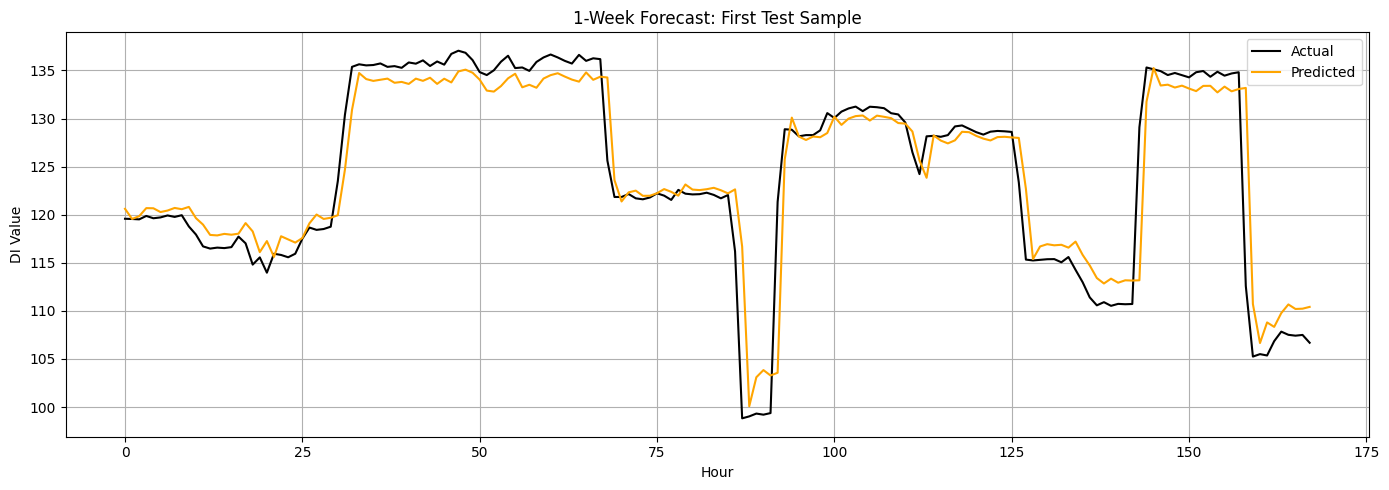

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#predict on test set
y_pred_scaled = model.predict([X_enc_test, X_dec_test])

# inverse scaled predictions
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_scaled.shape)
y_true = y_scaler.inverse_transform(y_dec_test.reshape(-1, 1)).reshape(y_dec_test.shape)

y_pred_flat = y_pred.flatten()
y_true_flat = y_true.flatten()

mae = mean_absolute_error(y_true_flat, y_pred_flat)
mse = mean_squared_error(y_true_flat, y_pred_flat)
r2 = r2_score(y_true_flat, y_pred_flat)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

#plot one week forecast vs actuals
plt.figure(figsize=(14, 5))
plt.plot(y_true[0], label="Actual", color='black')
plt.plot(y_pred[0], label="Predicted", color='orange')
plt.title("1-Week Forecast vs Actuals")
plt.xlabel("Hour")
plt.ylabel("DI Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


46/46 ━━━━━━━━━━━━━━━━━━━━ 23s 267ms/step
Evaluation on Test Set:
MAE: 3.12
MSE: 26.47
R² Score: 0.8309


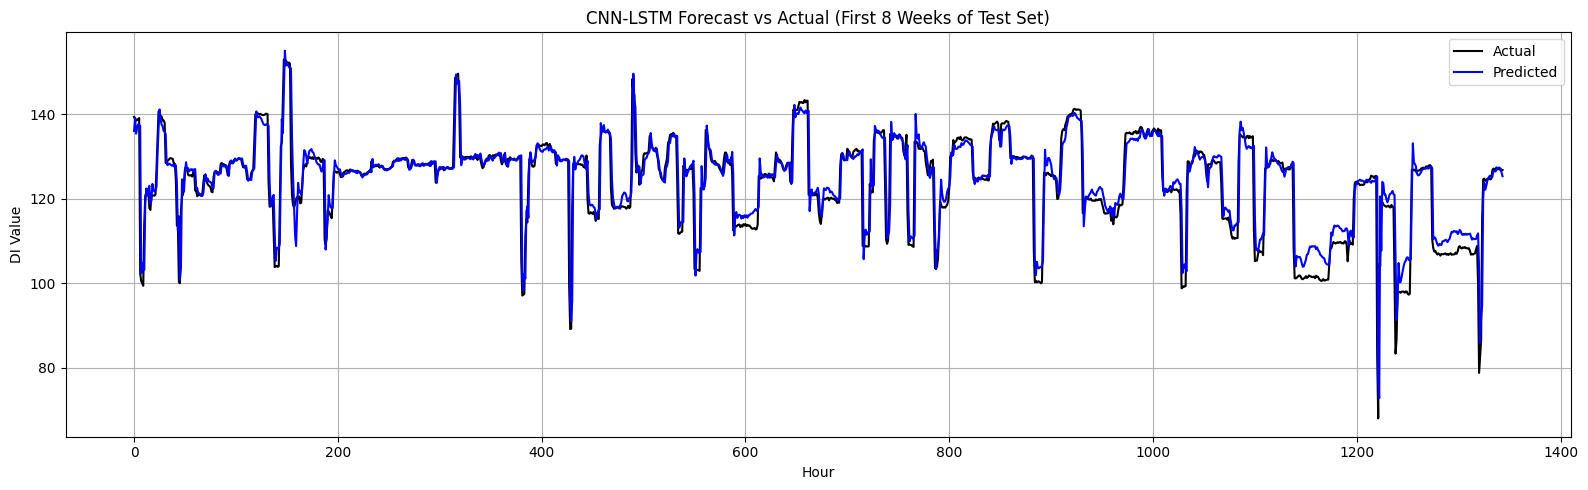

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Run predictions on test set
y_pred_scaled = model.predict([X_enc_test, X_dec_test])

#inverse transform predictions and true values
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_scaled.shape)
y_true = y_scaler.inverse_transform(y_dec_test.reshape(-1, 1)).reshape(y_dec_test.shape)

# flatten for metric calculation
y_pred_flat = y_pred.flatten()
y_true_flat = y_true.flatten()

#metrics
mae = mean_absolute_error(y_true_flat, y_pred_flat)
mse = mean_squared_error(y_true_flat, y_pred_flat)
r2 = r2_score(y_true_flat, y_pred_flat)

print("Evaluation on Test Set:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

#8 week window forecast
plt.figure(figsize=(16, 5))
plt.plot(y_true[0], label="Actual", color="black")
plt.plot(y_pred[0], label="Predicted", color="blue")
plt.title("CNN-LSTM Forecast vs Actual (First 8 Weeks of Test Set)")
plt.xlabel("Hour")
plt.ylabel("DI Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 283ms/step


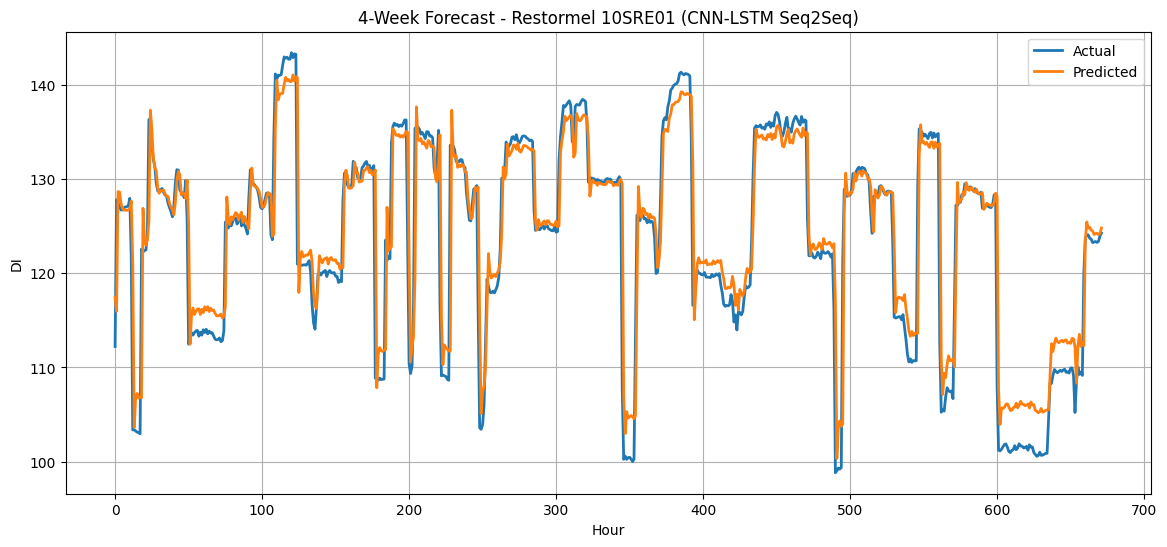

In [ ]:
y_pred = model.predict([X_enc_test, X_dec_test])

# Inverse transform
y_pred_inv = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(y_pred.shape)
y_test_inv = y_scaler.inverse_transform(y_dec_test.reshape(-1, 1)).reshape(y_dec_test.shape)

# Plot 4-week forecast example
plt.figure(figsize=(14, 6))
plt.plot(y_test_inv[0], label='Actual', linewidth=2)
plt.plot(y_pred_inv[0], label='Predicted', linewidth=2)
plt.title("4-Week Forecast - Restormel 10SRE01 (CNN-LSTM Seq2Seq)")
plt.xlabel("Hour")
plt.ylabel("DI")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Flatten the arrays for metric calculation
y_true_flat = y_test_inv.reshape(-1)
y_pred_flat = y_pred_inv.reshape(-1)

# Compute metrics
r2 = r2_score(y_true_flat, y_pred_flat)
mae = mean_absolute_error(y_true_flat, y_pred_flat)
mse = mean_squared_error(y_true_flat, y_pred_flat)

# Print results
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")


R² Score: 0.8499
Mean Absolute Error (MAE): 2.8308
Mean Squared Error (MSE): 23.8009
